In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [2]:
#LOAD DATA
df = pd.read_csv("surface_wqi_pred.csv")
print(f"Original dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nMissing values:\n{df.isna().sum()}")

Original dataset shape: (42, 23)

Columns: ['Site', 'Year', 'pH', 'Odour', 'Turbidity', 'Conductivity', 'Chloride (ppm)', 'Sulphates(ppm)', 'Iron (ppm)', 'COD(ppm)', 'BOD(ppm)', 'DO(ppm)', 'Lead(ppm)', 'Ammonia(ppm)', 'Nitrate(ppm)', 'Fluorides(ppm)', 'Phosphates(ppm)', 'Total Bacterial Count (cfu/ml)', 'Total Fungal Count (cfu/ml)', 'Pesticide (µg/l)', 'WQI', 'WQI_Class', 'WQI_Pred']

Missing values:
Site                               0
Year                               0
pH                                 0
Odour                             42
Turbidity                          0
Conductivity                       0
Chloride (ppm)                     0
Sulphates(ppm)                     0
Iron (ppm)                         0
COD(ppm)                           0
BOD(ppm)                           0
DO(ppm)                            0
Lead(ppm)                         42
Ammonia(ppm)                       0
Nitrate(ppm)                       0
Fluorides(ppm)                    30
Pho

In [3]:
# 2. DROP LEAKY / USELESS COLUMNS

# WQI_Pred: partial target column (only 13/42 filled) — direct leakage
# WQI_Class: categorical encoding of the target — direct leakage
# Odour, Lead, Pesticide: 100% NaN — no information
# Phosphates: 41/42 NaN — practically useless, imputer would hallucinate values
always_nan_or_useless = [
    col for col in df.columns
    if df[col].isna().all() or df[col].isna().sum() >= len(df) - 1
]
print(f"\nDropping near-empty columns: {always_nan_or_useless}")
df.drop(columns=always_nan_or_useless, errors='ignore', inplace=True)

# Drop target-leaking columns
for col in ["WQI_Pred", "WQI_Class", "Hotspot"]:
    if col in df.columns:
        print(f"Dropping '{col}' — target leakage")
        df.drop(columns=[col], inplace=True)


Dropping near-empty columns: ['Odour', 'Lead(ppm)', 'Phosphates(ppm)', 'Pesticide (µg/l)']
Dropping 'WQI_Pred' — target leakage
Dropping 'WQI_Class' — target leakage


In [4]:
# 3. CHECK IRON LEAKAGE

numeric_df = df.select_dtypes(include="number")
if "Iron (ppm)" in numeric_df.columns and "WQI" in numeric_df.columns:
    iron_corr = numeric_df["Iron (ppm)"].corr(numeric_df["WQI"])
    print(f"\nIron (ppm) ↔ WQI correlation: {iron_corr:.4f}")
    if abs(iron_corr) > 0.95:
        print("Iron (ppm) has near-perfect correlation with WQI → dropping (data leakage)")
        df.drop(columns=["Iron (ppm)"], inplace=True)
    else:
        print("Iron (ppm) correlation is acceptable — keeping as feature")


Iron (ppm) ↔ WQI correlation: 0.2192
Iron (ppm) correlation is acceptable — keeping as feature


In [5]:
# 4. FEATURE / TARGET SPLIT

X = df.select_dtypes(include="number").drop(columns=["WQI"])
y = df["WQI"]

print(f"\nFinal features ({X.shape[1]}): {list(X.columns)}")
print(f"Dataset size: {X.shape}")
print(f"\nRemaining missing values:\n{X.isna().sum().sort_values(ascending=False)}")


Final features (15): ['Year', 'pH', 'Turbidity', 'Conductivity', 'Chloride (ppm)', 'Sulphates(ppm)', 'Iron (ppm)', 'COD(ppm)', 'BOD(ppm)', 'DO(ppm)', 'Ammonia(ppm)', 'Nitrate(ppm)', 'Fluorides(ppm)', 'Total Bacterial Count (cfu/ml)', 'Total Fungal Count (cfu/ml)']
Dataset size: (42, 15)

Remaining missing values:
Fluorides(ppm)                    30
Total Fungal Count (cfu/ml)       18
Year                               0
pH                                 0
Turbidity                          0
Conductivity                       0
Chloride (ppm)                     0
Sulphates(ppm)                     0
Iron (ppm)                         0
COD(ppm)                           0
BOD(ppm)                           0
DO(ppm)                            0
Ammonia(ppm)                       0
Nitrate(ppm)                       0
Total Bacterial Count (cfu/ml)     0
dtype: int64


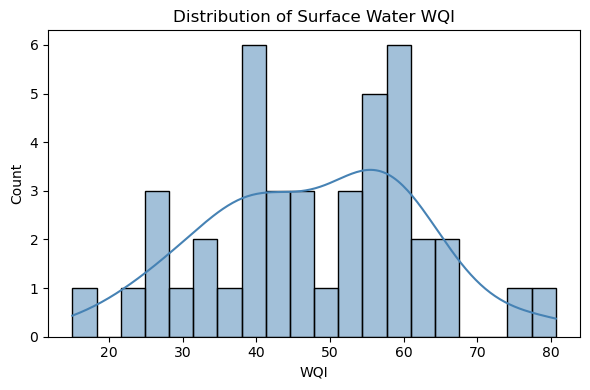

Saved: wqi_distribution.png


In [7]:
# 5. WQI DISTRIBUTION (EDA)

plt.figure(figsize=(6, 4))
sns.histplot(y, bins=20, kde=True, color='steelblue')
plt.title("Distribution of Surface Water WQI")
plt.xlabel("WQI")
plt.tight_layout()
plt.savefig("wqi_distribution.png", dpi=150)
plt.show()
print("Saved: wqi_distribution.png")

In [8]:
# 6. TRAIN-TEST SPLIT  (before any imputation or augmentation)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")


Train: (33, 15), Test: (9, 15)


In [9]:
# 7. DATA AUGMENTATION — Gaussian noise (training set only)

def augment_data(X, y, n_copies=3, noise_fraction=0.01, random_state=42):
    """
    Expand dataset by creating n_copies noisy versions of each training sample.
    Noise = Gaussian with std = noise_fraction × feature_std.
    Only applied to non-NaN values to preserve missing patterns.
    """
    rng = np.random.RandomState(random_state)
    feature_stds = X.std(skipna=True)
    X_list, y_list = [X.copy()], [y.copy()]
    for _ in range(n_copies):
        X_noisy = X.copy()
        for col in X.columns:
            std = feature_stds[col]
            if std == 0 or np.isnan(std):
                continue
            noise = rng.normal(0, noise_fraction * std, size=len(X))
            mask = X_noisy[col].notna()
            X_noisy.loc[mask, col] = X_noisy.loc[mask, col] + noise[mask]
        X_list.append(X_noisy)
        y_list.append(y + rng.normal(0, 0.005 * y.std(), size=len(y)))
    return pd.concat(X_list, ignore_index=True), pd.concat(y_list, ignore_index=True)

X_train_aug, y_train_aug = augment_data(X_train, y_train, n_copies=3)
print(f"After augmentation: train={X_train_aug.shape} (was {X_train.shape})")

After augmentation: train=(132, 15) (was (33, 15))


In [10]:
# 8. KNN IMPUTATION (fit on train only)

imputer = KNNImputer(n_neighbors=5)
X_train_imp = imputer.fit_transform(X_train_aug)
X_test_imp  = imputer.transform(X_test)

In [11]:
# 9. FEATURE SCALING

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

In [12]:
# 10. NSE METRIC

def nse(y_true, y_pred):
    """Nash-Sutcliffe Efficiency — standard metric in hydrological modelling"""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return 1 - (np.sum((y_true - y_pred) ** 2) /
                np.sum((y_true - np.mean(y_true)) ** 2))

In [13]:
# 11. HYPERPARAMETER TUNING (GridSearchCV)

print("\n--- Hyperparameter Tuning ---")

param_grids = {
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [None, 5, 10],
            "min_samples_split": [2, 5]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.05, 0.1, 0.2],
            "max_depth": [3, 5]
        }
    },
    "XGBoost": {
        "model": XGBRegressor(random_state=42, verbosity=0),
        "params": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5, 7]
        }
    },
    "SVM": {
        "model": SVR(),
        "params": {
            "C": [1, 10, 100],
            "gamma": ["scale", "auto", 0.1],
            "kernel": ["rbf", "linear"]
        }
    },
    "Decision Tree": {
        "model": DecisionTreeRegressor(random_state=42),
        "params": {
            "max_depth": [None, 3, 5, 10],
            "min_samples_split": [2, 5, 10]
        }
    }
}

# KFold CV — fixed: now uses training data only (not full X/y as in original)
kf5  = KFold(n_splits=5,  shuffle=True, random_state=42)
kf10 = KFold(n_splits=10, shuffle=True, random_state=42)

best_models   = {}
final_results = []

for name, cfg in param_grids.items():
    grid = GridSearchCV(cfg["model"], cfg["params"], cv=5, scoring="r2", n_jobs=-1)
    grid.fit(X_train_sc, y_train_aug)
    best_model = grid.best_estimator_
    best_models[name] = best_model

    y_pred = best_model.predict(X_test_sc)

    r2      = r2_score(y_test, y_pred)
    rmse    = np.sqrt(mean_squared_error(y_test, y_pred))
    mae     = mean_absolute_error(y_test, y_pred)
    nse_val = nse(y_test, y_pred)

    # CV on training set only — fixed from original which used full X/y
    cv5  = cross_val_score(best_model, X_train_sc, y_train_aug, cv=kf5,  scoring="r2")
    cv10 = cross_val_score(best_model, X_train_sc, y_train_aug, cv=kf10, scoring="r2")

    print(f"{name}: R²={r2:.3f} | Best: {grid.best_params_}")

    final_results.append([
        name, round(r2, 4), round(rmse, 4), round(mae, 4), round(nse_val, 4),
        f"{cv5.mean():.3f} ± {cv5.std():.3f}",
        f"{cv10.mean():.3f} ± {cv10.std():.3f}"
    ])


--- Hyperparameter Tuning ---
Random Forest: R²=0.872 | Best: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Gradient Boosting: R²=0.842 | Best: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
XGBoost: R²=0.861 | Best: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
SVM: R²=0.925 | Best: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
Decision Tree: R²=0.731 | Best: {'max_depth': None, 'min_samples_split': 2}


In [14]:
# 12. RESULTS TABLE

columns = ["Model", "R²", "RMSE", "MAE", "NSE", "5-Fold CV R²", "10-Fold CV R²"]
results_df = pd.DataFrame(final_results, columns=columns)
results_df = results_df.sort_values(by="R²", ascending=False).reset_index(drop=True)

print("\n=== SURFACE WATER REGRESSION RESULTS ===")
print(results_df.to_string(index=False))


=== SURFACE WATER REGRESSION RESULTS ===
            Model     R²   RMSE    MAE    NSE  5-Fold CV R² 10-Fold CV R²
              SVM 0.9253 4.8480 3.8992 0.9253 0.995 ± 0.010 1.000 ± 0.000
    Random Forest 0.8717 6.3548 4.3407 0.8717 0.982 ± 0.016 0.996 ± 0.004
          XGBoost 0.8614 6.6049 4.0009 0.8614 0.980 ± 0.014 0.986 ± 0.015
Gradient Boosting 0.8422 7.0453 5.3579 0.8422 0.999 ± 0.001 0.999 ± 0.001
    Decision Tree 0.7310 9.1992 6.9126 0.7310 0.999 ± 0.002 0.999 ± 0.002


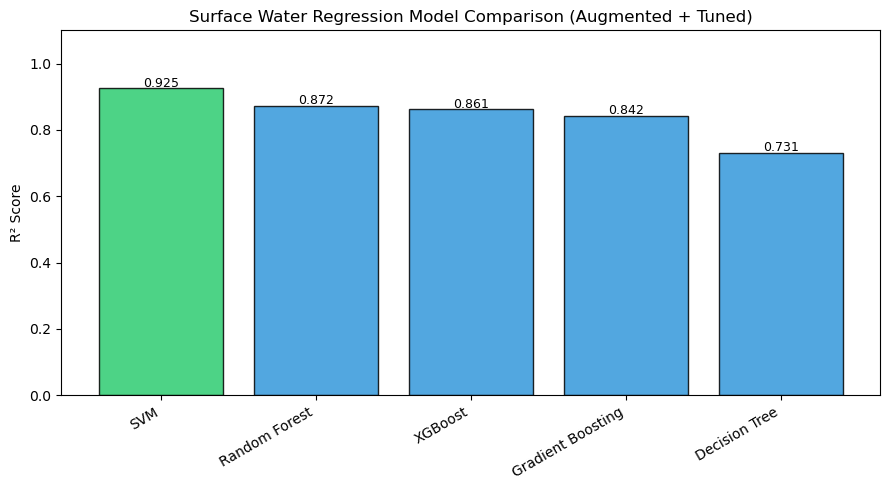

Saved: model_comparison.png


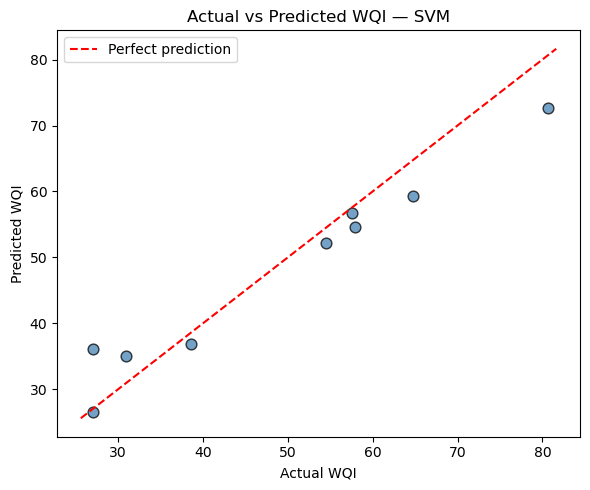

Saved: actual_vs_predicted.png


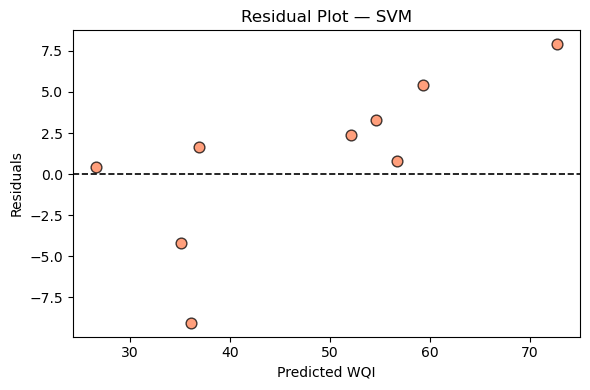

Saved: residuals.png


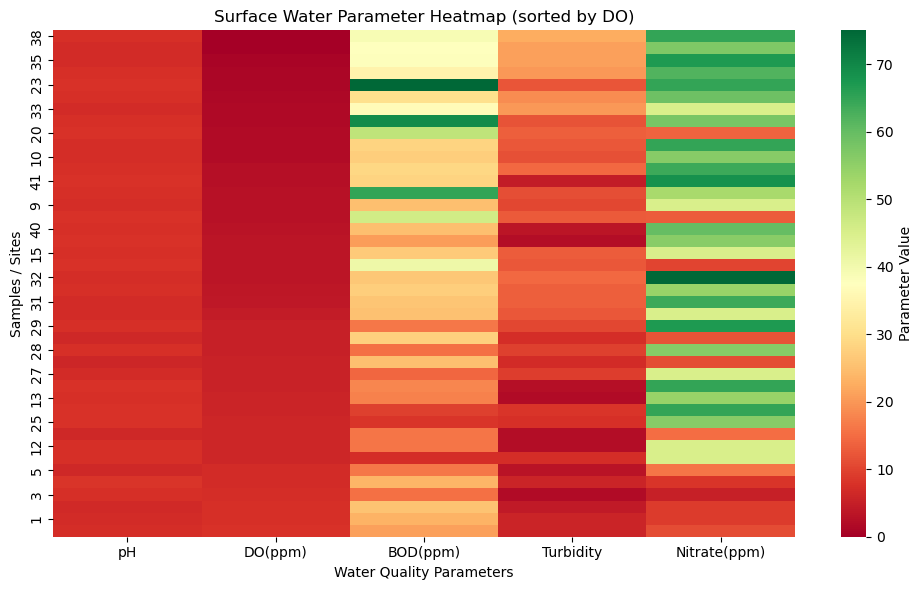

Saved: parameter_heatmap.png


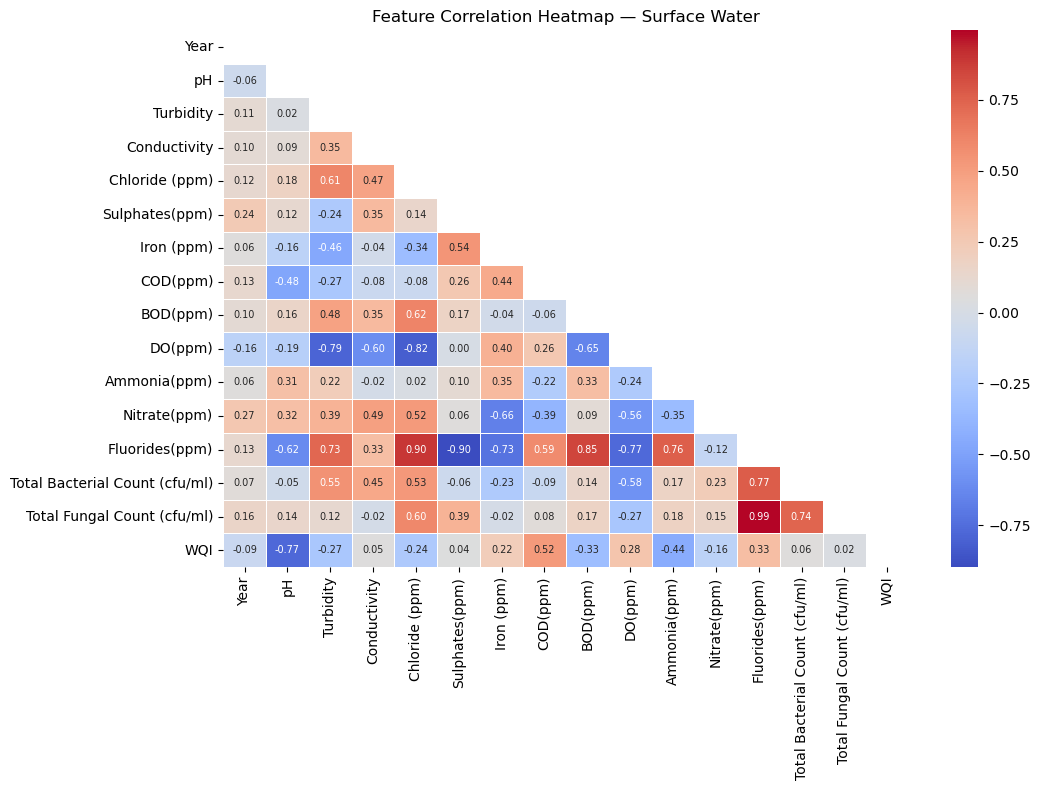

Saved: correlation_heatmap.png


In [15]:
# 13. PLOTS

# Model comparison bar chart
plt.figure(figsize=(9, 5))
bar_colors = ['#2ecc71' if r == results_df['R²'].max() else '#3498db'
              for r in results_df['R²']]
bars = plt.bar(results_df["Model"], results_df["R²"],
               color=bar_colors, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, results_df['R²']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.ylabel("R² Score")
plt.title("Surface Water Regression Model Comparison (Augmented + Tuned)")
plt.ylim(0, 1.1)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()
print("Saved: model_comparison.png")

# Actual vs Predicted — best model
best_name  = results_df.iloc[0]["Model"]
best_model = best_models[best_name]
y_pred_best = best_model.predict(X_test_sc)

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_best, alpha=0.75, color='steelblue',
            edgecolors='black', s=60)
lims = [min(y_test.min(), y_pred_best.min()) - 1,
        max(y_test.max(), y_pred_best.max()) + 1]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel("Actual WQI")
plt.ylabel("Predicted WQI")
plt.title(f"Actual vs Predicted WQI — {best_name}")
plt.legend()
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150)
plt.show()
print("Saved: actual_vs_predicted.png")

# Residual plot
residuals = np.array(y_test) - y_pred_best
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_best, residuals, alpha=0.75, color='coral',
            edgecolors='black', s=60)
plt.axhline(0, color='black', linewidth=1.2, linestyle='--')
plt.xlabel("Predicted WQI")
plt.ylabel("Residuals")
plt.title(f"Residual Plot — {best_name}")
plt.tight_layout()
plt.savefig("residuals.png", dpi=150)
plt.show()
print("Saved: residuals.png")

# NSF-style parameter heatmap (fixed: using raw values, not scaled)
qi_cols = [c for c in ["pH", "DO(ppm)", "BOD(ppm)", "Turbidity", "Nitrate(ppm)"]
           if c in df.columns]
plt.figure(figsize=(10, 6))
sns.heatmap(
    df[qi_cols].sort_values("DO(ppm)" if "DO(ppm)" in qi_cols else qi_cols[0]),
    cmap="RdYlGn",
    cbar_kws={"label": "Parameter Value"}
)
plt.title("Surface Water Parameter Heatmap (sorted by DO)")
plt.xlabel("Water Quality Parameters")
plt.ylabel("Samples / Sites")
plt.tight_layout()
plt.savefig("parameter_heatmap.png", dpi=150)
plt.show()
print("Saved: parameter_heatmap.png")

# Full feature correlation heatmap
plt.figure(figsize=(11, 8))
corr = df.select_dtypes(include="number").corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            annot_kws={"size": 7}, linewidths=0.4)
plt.title("Feature Correlation Heatmap — Surface Water")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()
print("Saved: correlation_heatmap.png")

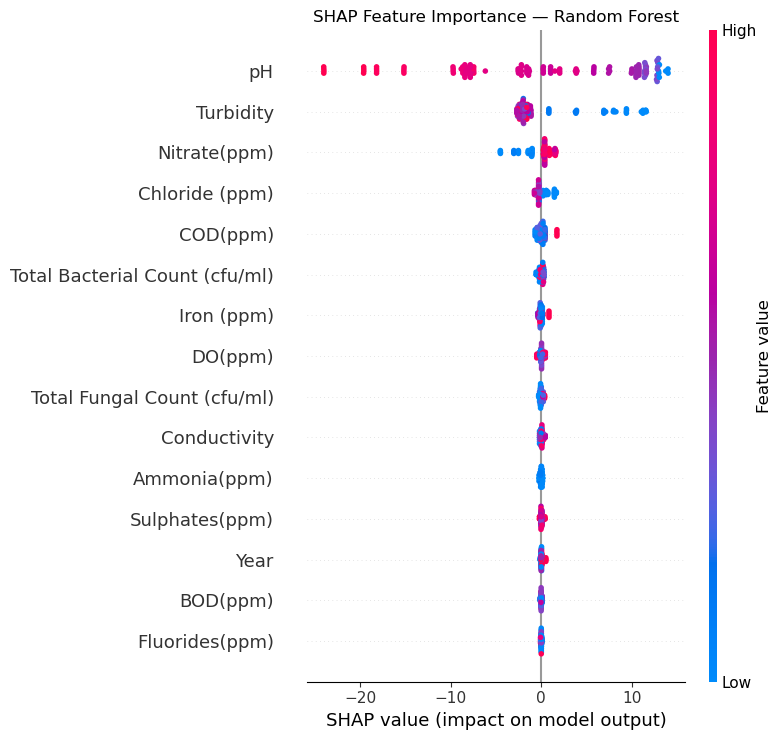

Saved: shap_summary.png

 Done! Best model: SVM
Model                      SVM
R²                      0.9253
RMSE                     4.848
MAE                     3.8992
NSE                     0.9253
5-Fold CV R²     0.995 ± 0.010
10-Fold CV R²    1.000 ± 0.000
Name: 0, dtype: object


In [16]:
# 14. SHAP ANALYSIS

try:
    import shap

    # Pick best tree-based model for SHAP
    shap_model_name = None
    for preferred in ["Random Forest", "Gradient Boosting", "XGBoost", "Decision Tree"]:
        if preferred in best_models:
            shap_model_name = preferred
            break

    shap_model = best_models[shap_model_name]
    feature_names = list(X.columns)

    explainer   = shap.TreeExplainer(shap_model)
    shap_sample = X_train_sc[:200] if len(X_train_sc) > 200 else X_train_sc
    shap_values = explainer.shap_values(shap_sample)

    shap.summary_plot(shap_values, shap_sample,
                      feature_names=feature_names, show=False)
    plt.title(f"SHAP Feature Importance — {shap_model_name}")
    plt.tight_layout()
    plt.savefig("shap_summary.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: shap_summary.png")

except ImportError:
    print("SHAP not installed. Run: pip install shap")

print(f"\n Done! Best model: {best_name}")
print(results_df.iloc[0])